# Code Review - ResNet
교재 : 딥러닝 파이토치 교과서  
범위 : 6.1.5장 ResNet



## Import

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import matplotlib.pyplot as plt
import numpy as np

import copy
from collections import namedtuple # 인덱스뿐만 아니라 키 값으로도 데이터에 접근 가능한 튜플 자료형
import os
import random
import time

import cv2
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# GPU 사용 가능 여부에 따라 device 설정 (가능하면 cuda, 아니면 cpu)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Preprocessing

In [3]:
# 이미지 데이터 전처리 클래스

class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            # 훈련 이미지 데이터에 대한 전처리
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)), # RandomResizedCrop: 원본 대비 0.5~1.0 크기로 랜덤 크롭 후, resize 크기로 조정
                transforms.RandomHorizontalFlip(),                      # RandomHorizontalFlip: 랜덤 좌우 반전
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            # 검증과 테스트 이미지 데이터에 대한 전처리
            'val': transforms.Compose([
                transforms.Resize(256),                                 # Resize: 이미지 크기를 256x256으로 조정
                transforms.CenterCrop(resize),                          # CenterCrop: 중앙 기준으로 잘라 resize 크기로 통일
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img) # phase에 해당하는 전처리 적용

In [4]:
# 데이터 전처리 변수
size = 224                   # 모델에 입력할 이미지 크기
mean = (0.485, 0.456, 0.406) # RGB 채널별 평균값(ImageNet 기준)
std = (0.229, 0.224, 0.225)  # RGB 채널별 표준편차(ImageNet 기준)
batch_size = 32              # 한번에 학습할 데이터 수

## Dataset

**Load data**   
dogs-vs-cats 데이터 사용

In [5]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [6]:
# dogs-vs-cats 데이터의 파일 경로를 저장

data_directory = r'./drive/MyDrive/Euron/data/dogs-vs-cats'
cat_directory = os.path.join(data_directory,'cat')
dog_directory = os.path.join(data_directory,'dog')

# 각 디렉토리의 파일 경로를 정렬하여 리스트로 저장
cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])

images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]  # 두 리스트를 하나로 합침
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None] # cv2로 실제로 읽을 수 있는 이미지만 필터링

**Split data**

In [7]:
# Train, validation, test 데이터로 분리

random.seed(42) # 재현성을 위한 랜덤 시드 고정
random.shuffle(correct_images_filepaths) # 데이터 랜덤 정렬
train_images_filepaths = correct_images_filepaths[:400]    # Train
val_images_filepaths = correct_images_filepaths[400:-10]   # Validation
test_images_filepaths = correct_images_filepaths[-10:]     # Test
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 89 10


**Dataset class**

In [8]:
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)                        # 인덱스에 해당하는 이미지 로드
        img_transformed = self.transform(img, self.phase) # Phase에 따라 이미지 전처리

        # 파일명에서 정답 라벨 추출 : 경로의 마지막 파일명에서 확장자 제거 후 dog/cat 판별
        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label # 변형된 이미지, 정답 라벨 반환

In [9]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

# 데이터셋 확인: index 0의 이미지 크기와 레이블 출력
index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 224, 224])
0


- 이미지 채널 크기 3은 RGB를 의미하여, 이미지는 resize를 통해 224x224로 변형된 것을 확인
- 라벨 0은 고양이를 의미

**Data Loader**

In [10]:
train_iterator  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_iterator = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_iterator, 'val': valid_iterator}

# 첫 번째 배치 확인
batch_iterator = iter(train_iterator)   # DataLoader를 순회 가능한 Iterator 객체로 반환
inputs, label = next(batch_iterator)    # 배치 하나 가져오기
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
        1, 0, 1, 1, 0, 0, 0, 0])


- 배치 한 개는 3x224x224 크기의 이미지 32개로 구성
- 라벨은 32개 데이터의 정답 클래스 리스트

## Model

**Define Model Class**

In [11]:
# BasicBlock: 3x3 Conv 2개로 구성된 블록으로 ResNet18, ResNet34에서 사용

class BasicBlock(nn.Module):
    expansion = 1  # BasicBlock은 채널 수를 그대로 유지 (확장 없음)

    def __init__(self, in_channels, out_channels, stride = 1, downsample = False):
        super().__init__()

        # 3x3 Conv 2개로 특징 추출
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1, bias = False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = 1, padding = 1, bias = False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace = True)

        if downsample: # 입력 데이터와 블록 통과 후 출력 데이터의 크기가 다른 경우, 1x1 Conv에 stride를 적용해 크기 조정
            conv = nn.Conv2d(in_channels, out_channels, kernel_size = 1, stride = stride, bias = False)
            bn = nn.BatchNorm2d(out_channels)
            downsample = nn.Sequential(conv, bn)
        else: # 입출력 크기가 같은 경우
            downsample = None
        self.downsample = downsample

    def forward(self, x):
        i = x   # Residual connection을 위해 입력 저장
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)

        if self.downsample is not None: # 입출력 크기 다른 경우 downsampling
            i = self.downsample(i)

        x += i  # Identity mapping: 블록의 출력에 원래 입력을 그대로 더함
        x = self.relu(x)

        return x

In [12]:
# Bottleneck block: 1x1 Conv → 3x3 Conv → 1x1 Conv로 구성된 블록으로 ResNet50, ResNet101, ResNet152에서 사용
# -> BasicBlock 대비 더 깊은 층을 쌓으면서 연산 비용을 줄이고, 더 많은 비선형성(non-linearity)을 처리할 수 있음

class Bottleneck(nn.Module):
    expansion = 4   # Bottleneck block은 출력 채널 수를 4배 확장

    def __init__(self, in_channels, out_channels, stride = 1, downsample = False):
        super().__init__()

        # 1x1 Conv: 채널 축소
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size = 1, stride = 1, bias = False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # 3x3 Conv: 특징 추출
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = stride, padding = 1, bias = False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        # 1x1 Conv: 채널 확장 -> expansion 만큼 채널 수를 확장
        self.conv3 = nn.Conv2d(out_channels, self.expansion * out_channels, kernel_size = 1, stride = 1, bias = False)
        self.bn3 = nn.BatchNorm2d(self.expansion * out_channels)
        self.relu = nn.ReLU(inplace = True)

        if downsample: # 입출력 크기가 다른 경우
            conv = nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size = 1, stride = stride, bias = False)
            bn = nn.BatchNorm2d(self.expansion * out_channels)
            downsample = nn.Sequential(conv, bn)
        else: # 입출력 크기가 같은 경우
            downsample = None
        self.downsample = downsample

    def forward(self, x):
        i = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)

        if self.downsample is not None:
            i = self.downsample(i)

        x += i
        x = self.relu(x)

        return x

In [13]:
# ResNet model class : config로 블록 종류, 블록 수, 채널 수를 받아 다양한 ResNet 생성

class ResNet(nn.Module):
    def __init__(self, config, output_dim, zero_init_residual=False):
        super().__init__()

        block, n_blocks, channels = config  # ResNetConfig에서 블록 종류, 블록 수, 채널 수 언패킹
        self.in_channels = channels[0]
        assert len(n_blocks) == len(channels) == 4  # 블록 수와 채널 수 정보가 layer 개수(4개)만큼 주어졌는지 확인

        # 7×7 Conv로 초기 특징 추출
        self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size = 7, stride = 2, padding = 3, bias = False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace = True)
        self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        # 4개의 ResNet layer(각 레이어는 여러 블록으로 구성)
        self.layer1 = self.get_resnet_layer(block, n_blocks[0], channels[0])
        self.layer2 = self.get_resnet_layer(block, n_blocks[1], channels[1], stride = 2)
        self.layer3 = self.get_resnet_layer(block, n_blocks[2], channels[2], stride = 2)
        self.layer4 = self.get_resnet_layer(block, n_blocks[3], channels[3], stride = 2)

        # AdaptiveAvgPool: 입력 크기와 무관하게 출력을 1x1로 고정
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

        # Linear layer : 최종 클래스 분류를 위한 fully connected layer
        self.fc = nn.Linear(self.in_channels, output_dim)

        # zero_init_residual: 각 residual branch의 마지막 BN 가중치를 0으로 초기화 -> 모델 성능 0.2~0.3% 향상 효과
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def get_resnet_layer(self, block, n_blocks, channels, stride = 1):
        # 블록을 쌓아 하나의 ResNet layer를 만드는 함수

        layers = []

        # 현재 입력의 채널 수(in_channels)와 block의 채널 수(block.expansion*channels)가 다르면 downsampling
        if self.in_channels != block.expansion * channels:
            downsample = True
        else:
            downsample = False

        # 첫 번째 블록 추가
        layers.append(block(self.in_channels, channels, stride, downsample)) # 첫 번째 블록에서만 downsampling을 수행하므로 stride, downsample 여부까지 매개변수로 전달

        # 나머지 블록 (n_blocks - 1)개 추가
        for i in range(1, n_blocks):
            layers.append(block(block.expansion * channels, channels))

        self.in_channels = block.expansion * channels # 현재 입력의 채널 수 업데이트
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1) # Flatten: [batch, channels, 1, 1] → [batch, channels]
        x = self.fc(h)
        return x, h

In [14]:
# ResNet config 정의

ResNetConfig = namedtuple('ResNetConfig', ['block', 'n_blocks', 'channels'])

In [15]:
# BasicBlock을 사용하는 ResNet18, ResNet34 config

resnet18_config = ResNetConfig(block = BasicBlock,
                               n_blocks = [2,2,2,2],
                               channels = [64, 128, 256, 512])

resnet34_config = ResNetConfig(block = BasicBlock,
                               n_blocks = [3,4,6,3],
                               channels = [64, 128, 256, 512])


# Bottleneck block을 사용하는 ResNet50, ResNet101, ResNet152 config

resnet50_config = ResNetConfig(block = Bottleneck,
                               n_blocks = [3, 4, 6, 3],
                               channels = [64, 128, 256, 512])

resnet101_config = ResNetConfig(block = Bottleneck,
                                n_blocks = [3, 4, 23, 3],
                                channels = [64, 128, 256, 512])

resnet152_config = ResNetConfig(block = Bottleneck,
                                n_blocks = [3, 8, 36, 3],
                                channels = [64, 128, 256, 512])

**Network Architecture**

In [16]:
# Pretrained 모델: torchvision.models에서 pretrained=True로 ImageNet 학습 가중치 로드
pretrained_model = models.resnet50(pretrained = True)
print(pretrained_model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [17]:
# 직접 정의한 모델
OUTPUT_DIM = 2  # 개와 고양이 두 클래스 분류
model = ResNet(resnet50_config, OUTPUT_DIM) # ResNet50
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# Train

**Setup**

In [37]:
# Optimizer, Loss function, Model 정의

optimizer = optim.Adam(model.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss() # CrossEntropyLoss: 다중 클래스 분류에 적합한 손실 함수

model = model.to(device)
criterion = criterion.to(device)

In [38]:
# 모델 학습 정확도 측정 함수: top-1 정확도와 top-k 정확도 반환

def calculate_topk_accuracy(y_pred, y, k = 2):
    with torch.no_grad():
        batch_size = y.shape[0]
        _, top_pred = y_pred.topk(k, 1) # topk: 예측 결과에서 가장 확률이 높은 k개의 인덱스 반환
        top_pred = top_pred.t()         # t: 차원0과 1을 전치(transpose) -> top_pred를 [batch, k]에서 [k, batch]로 변환
        correct = top_pred.eq(y.view(1, -1).expand_as(top_pred)) # eq: 예측과 정답 텐서를 비교하여 서로 같으면 True, 다르면 False 반환

        # top-1 정확도: 첫 번째 예측이 정답인 비율
        correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim = True)
        # top-k 정확도: 상위 k개 예측 중 정답이 있는 비율
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim = True)

        acc_1 = correct_1 / batch_size
        acc_k = correct_k / batch_size
    return acc_1, acc_k

In [39]:
# 모델 학습 함수
def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc_1 = 0
    epoch_acc_5 = 0

    model.train()  # 학습 모드
    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()  # Gradient 초기화
        y_pred = model(x)      # 순전파 예측

        loss = criterion(y_pred[0], y)  # 손실 계산
        acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)  # 정확도 계산

        loss.backward()        # 역전파 gradient 계산
        optimizer.step()       # 가중치 업데이트

        epoch_loss += loss.item()
        epoch_acc_1 += acc_1.item()
        epoch_acc_5 += acc_5.item()

    # 배치 수로 나눠 epoch 평균 손실/정확도 계산
    epoch_loss /= len(iterator)
    epoch_acc_1 /= len(iterator)
    epoch_acc_5 /= len(iterator)

    return epoch_loss, epoch_acc_1, epoch_acc_5

In [40]:
# 모델 평가 함수
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc_1 = 0
    epoch_acc_5 = 0

    model.eval()  # 평가 모드
    with torch.no_grad():  # Gradient 계산 비활성화
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)  # 순전파 예측

            loss = criterion(y_pred[0], y)  # 손실 계산
            acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y) # 정확도 계산

            epoch_loss += loss.item()
            epoch_acc_1 += acc_1.item()
            epoch_acc_5 += acc_5.item()

    epoch_loss /= len(iterator)
    epoch_acc_1 /= len(iterator)
    epoch_acc_5 /= len(iterator)
    return epoch_loss, epoch_acc_1, epoch_acc_5

In [41]:
# 모델 학습 시간 측정 함수
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time  # 한 epoch 수행 시간(초)

    # n초 -> n분 n초로 변환
    elapsed_mins = int(elapsed_time / 60) # 분 계산
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60)) # 나머지 초 계산
    return elapsed_mins, elapsed_secs

**Train**

In [42]:
best_valid_loss = float('inf') # 최적 검증 손실 초기값을 무한대로 설정
EPOCHS = 10

for epoch in range(EPOCHS):
    start_time = time.monotonic()

    # Train & validation
    train_loss, train_acc_1, train_acc_5 = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc_1, valid_acc_5 = evaluate(model, valid_iterator, criterion, device)

    # Validation loss가 이전보다 낮아지면 모델 저장
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), './drive/MyDrive/Euron/data/ResNet-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time) # epoch 수행 시간 계

    # epoch별 학습 결과 출력
    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc @1: {train_acc_1*100:6.2f}% | ' \
          f'Train Acc @5: {train_acc_5*100:6.2f}%')
    print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc @1: {valid_acc_1*100:6.2f}% | ' \
          f'Valid Acc @5: {valid_acc_5*100:6.2f}%')

Epoch: 01 | Epoch Time: 0m 7s
	Train Loss: 0.693 | Train Acc @1:  52.64% | Train Acc @5: 100.00%
	Valid Loss: 0.686 | Valid Acc @1:  50.37% | Valid Acc @5: 100.00%
Epoch: 02 | Epoch Time: 0m 7s
	Train Loss: 0.683 | Train Acc @1:  53.85% | Train Acc @5: 100.00%
	Valid Loss: 0.688 | Valid Acc @1:  53.04% | Valid Acc @5: 100.00%
Epoch: 03 | Epoch Time: 0m 9s
	Train Loss: 0.693 | Train Acc @1:  51.44% | Train Acc @5: 100.00%
	Valid Loss: 0.683 | Valid Acc @1:  53.04% | Valid Acc @5: 100.00%
Epoch: 04 | Epoch Time: 0m 8s
	Train Loss: 0.690 | Train Acc @1:  51.92% | Train Acc @5: 100.00%
	Valid Loss: 0.685 | Valid Acc @1:  54.08% | Valid Acc @5: 100.00%
Epoch: 05 | Epoch Time: 0m 9s
	Train Loss: 0.684 | Train Acc @1:  54.57% | Train Acc @5: 100.00%
	Valid Loss: 0.686 | Valid Acc @1:  53.79% | Valid Acc @5: 100.00%
Epoch: 06 | Epoch Time: 0m 7s
	Train Loss: 0.694 | Train Acc @1:  51.68% | Train Acc @5: 100.00%
	Valid Loss: 0.679 | Valid Acc @1:  56.17% | Valid Acc @5: 100.00%
Epoch: 07 | Epoc

# Test

In [43]:
# Test 데이터셋으로 예측: 각 테스트 이미지에 대해 개/고양이 확률을 예측하고 CSV로 저장

import pandas as pd

id_list = []
pred_list = []
_id=0

with torch.no_grad():  # Gradient 계산 비활성화
    for test_path in test_images_filepaths:  # Test 이미지 경로 순회
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1]  # 파일명에서 id 추출

        # 이미지 전처리
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')

        img = img.unsqueeze(0)  # 배치 차원 추가: [C, H, W] → [1, C, H, W]
        img = img.to(device)

        # 예측 및 결과 저장
        model.eval()  # 평가 모드

        outputs = model(img)  # 순전파 예측
        preds = F.softmax(outputs[0], dim=1)[:, 1].tolist()  # Softmax로 확률로 변환 후, 클래스 1(dog)의 확률 추출

        id_list.append(_id)         # id list에 id 추가
        pred_list.append(preds[0])  # pred list에 클래스 1에 대한 확률값 추가

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list  # > 0.5: dog, < 0.5: cat
})

res.sort_values(by='id', inplace=True)   # id 기준 정렬
res.reset_index(drop=True, inplace=True) # 인덱스 초기화

res.to_csv('./drive/MyDrive/Euron/data/ResNet.csv', index=False)
res.head(10)

,id,label
0,110,0.571097
1,147,0.502291
2,151,0.571301
3,164,0.495212
4,17,0.522132
5,202,0.594098
6,212,0.590230
7,214,0.529355
8,216,0.485401
9,226,0.527078


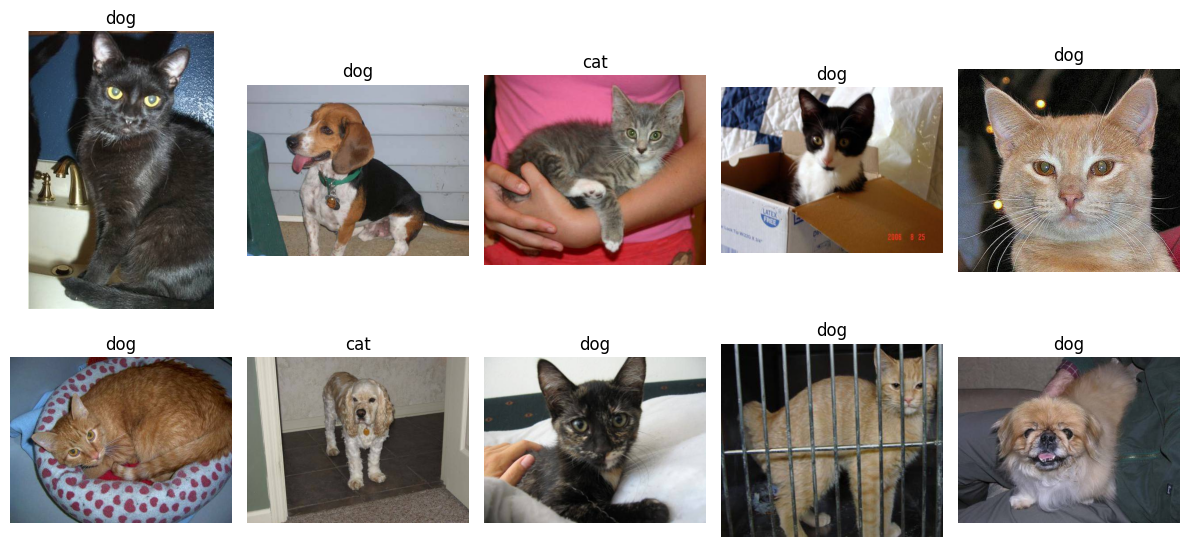

In [44]:
# Test 예측 결과 시각화

class_ = classes = {0:'cat', 1:'dog'} # Label을 클래스명으로 매핑

def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        # 이미지 로드
        _id = image_filepath.split('/')[-1].split('.')[1]
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # BGR → RGB (OpenCV는 BGR이 기)

        # 이미지에 해당하는 예측 레이블 가져오기
        label = res.loc[res['id'] == _id, 'label'].values[0]

        # label > 0.5: dog(1), label <= 0.5: cat(0)
        if label > 0.5:
            label = 1
        else:
            label = 0

        # 시각화
        ax.ravel()[i].imshow(image)  # ravel: 2차원의 ax 배열을 1차원으로 펼치는 함수
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()
display_image_grid(test_images_filepaths)